# Galaxy10 DECaLS training with PyTorch

This notebook compares a deliberately small set of CNN configurations on the validation split. The test split is evaluated exactly once after selection. No metric in this unexecuted notebook is a portfolio result.

In [1]:
from copy import deepcopy
import gc
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix
from torch import nn

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from galaxy_classification.galaxy10 import (
    GALAXY10_CLASS_NAMES, GALAXY10_FILENAME, GALAXY10_SHAPE,
    Galaxy10CNN, Galaxy10TrainingConfig, class_weights, make_loaders,
    run_epoch, seed_everything, validate_manifest,
)

ARRAY_PATH = ROOT / 'data' / 'processed' / 'galaxy10-images.npy'
MANIFEST_PATH = ROOT / 'data' / 'image-manifests' / 'galaxy10-decals.csv'
manifest = pd.read_csv(MANIFEST_PATH)
validate_manifest(manifest, GALAXY10_SHAPE[0])
if not torch.cuda.is_available():
    raise RuntimeError(
        'CUDA is unavailable. Install requirements-gpu.txt and restart the kernel.'
    )
DEVICE = torch.device('cuda')
print('PyTorch:', torch.__version__)
print('CUDA runtime:', torch.version.cuda)
print('GPU:', torch.cuda.get_device_name(0))
print('Compute capability:', torch.cuda.get_device_capability(0))
DEVICE

PyTorch: 2.9.0+cu128
CUDA runtime: 12.8
GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Compute capability: (12, 0)


device(type='cuda')

## Bounded training-only search

Learning rate and dropout vary across six bounded candidates. Class weights are calculated from the training split. Selection uses validation macro-F1, with early stopping; the test loader is not touched here.

In [2]:
CANDIDATES = [
    Galaxy10TrainingConfig(
        learning_rate=learning_rate, base_channels=32, dropout=dropout, epochs=10
    )
    for learning_rate in (1e-3, 3e-4)
    for dropout in (0.3, 0.5, 0.7)
]
EARLY_STOPPING_PATIENCE = 3
NUMBER_OF_WORKERS = 2
weights = class_weights(manifest).to(DEVICE)
loss_function = nn.CrossEntropyLoss(weight=weights)

In [3]:
def fit_candidate(config, candidate_number, total_candidates):
    print(f'\nCandidate {candidate_number}/{total_candidates}: learning_rate={config.learning_rate:g}, dropout={config.dropout:.1f}', flush=True)
    seed_everything(config.random_state)
    loaders = make_loaders(
        ARRAY_PATH, manifest, config, number_of_workers=NUMBER_OF_WORKERS
    )
    model = Galaxy10CNN(config.base_channels, config.dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    best_state = None
    best_macro_f1 = -1.0
    stale_epochs = 0
    history = []
    for epoch in range(config.epochs):
        train_metrics = run_epoch(
            model, loaders['train'], loss_function, DEVICE, optimizer
        )
        validation_metrics = run_epoch(
            model, loaders['validation'], loss_function, DEVICE
        )
        history.append({
            'epoch': epoch + 1,
            **{f'train_{key}': value for key, value in train_metrics.items()},
            **{f'validation_{key}': value for key, value in validation_metrics.items()},
        })
        if validation_metrics['macro_f1'] > best_macro_f1:
            best_macro_f1 = validation_metrics['macro_f1']
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            stale_epochs = 0
        else:
            stale_epochs += 1
        print(f'  epoch {epoch + 1:02d}/{config.epochs} | train_loss={train_metrics["loss"]:.4f} train_acc={train_metrics["accuracy"]:.4f} | val_loss={validation_metrics["loss"]:.4f} val_acc={validation_metrics["accuracy"]:.4f} val_balanced_acc={validation_metrics["balanced_accuracy"]:.4f} val_macro_f1={validation_metrics["macro_f1"]:.4f} best={best_macro_f1:.4f}', flush=True)
        if stale_epochs >= EARLY_STOPPING_PATIENCE:
            print('  early stopping: validation metric did not improve', flush=True)
            break
    del model, loaders
    gc.collect()
    torch.cuda.empty_cache()
    print(f'  candidate complete: best validation macro-F1={best_macro_f1:.4f}', flush=True)
    return best_state, pd.DataFrame(history), best_macro_f1

In [4]:
candidate_results = []
for candidate_number, config in enumerate(CANDIDATES, start=1):
    state, history, best_macro_f1 = fit_candidate(config, candidate_number, len(CANDIDATES))
    candidate_results.append({
        'config': config, 'state': state,
        'history': history, 'validation_macro_f1': best_macro_f1,
    })
print('\nGrid search complete. Validation ranking:', flush=True)
selection_table = pd.DataFrame([
    {
        'learning_rate': result['config'].learning_rate,
        'base_channels': result['config'].base_channels,
        'dropout': result['config'].dropout,
        'validation_macro_f1': result['validation_macro_f1'],
    }
    for result in candidate_results
]).sort_values('validation_macro_f1', ascending=False)
selection_table


Candidate 1/6: learning_rate=0.001, dropout=0.3
  epoch 01/10 | train_loss=2.0798 train_acc=0.2255 | val_loss=2.0049 val_acc=0.2376 val_balanced_acc=0.2282 val_macro_f1=0.1800 best=0.1800
  epoch 02/10 | train_loss=1.9017 train_acc=0.2839 | val_loss=1.9921 val_acc=0.2586 val_balanced_acc=0.2689 val_macro_f1=0.2381 best=0.2381
  epoch 03/10 | train_loss=1.8144 train_acc=0.3242 | val_loss=1.7064 val_acc=0.3737 val_balanced_acc=0.3565 val_macro_f1=0.3410 best=0.3410
  epoch 04/10 | train_loss=1.7519 train_acc=0.3504 | val_loss=1.7985 val_acc=0.3331 val_balanced_acc=0.3060 val_macro_f1=0.2891 best=0.3410
  epoch 05/10 | train_loss=1.7164 train_acc=0.3646 | val_loss=1.7424 val_acc=0.3470 val_balanced_acc=0.3624 val_macro_f1=0.3100 best=0.3410
  epoch 06/10 | train_loss=1.6809 train_acc=0.3788 | val_loss=1.7420 val_acc=0.3575 val_balanced_acc=0.3399 val_macro_f1=0.3107 best=0.3410
  early stopping: validation metric did not improve
  candidate complete: best validation macro-F1=0.3410

Cand

,learning_rate,base_channels,dropout,validation_macro_f1
1,0.0010,32,0.5,0.424936
4,0.0003,32,0.5,0.391975
3,0.0003,32,0.3,0.387961
5,0.0003,32,0.7,0.369757
0,0.0010,32,0.3,0.341045
2,0.0010,32,0.7,0.266893


## Retrain the selected configuration

The grid search selected the configuration using validation macro-F1. Now retrain that configuration for up to 80 epochs, selecting checkpoints with validation accuracy and allowing 25 stale epochs before stopping. The test split remains untouched.

In [5]:
selected = max(candidate_results, key=lambda item: item['validation_macro_f1'])
final_config = Galaxy10TrainingConfig(
    learning_rate=selected['config'].learning_rate,
    base_channels=selected['config'].base_channels,
    dropout=selected['config'].dropout,
    batch_size=selected['config'].batch_size,
    epochs=80,
    random_state=selected['config'].random_state,
)
FINAL_EARLY_STOPPING_PATIENCE = 25
seed_everything(final_config.random_state)
final_loaders = make_loaders(
    ARRAY_PATH, manifest, final_config, number_of_workers=NUMBER_OF_WORKERS
)
final_model = Galaxy10CNN(final_config.base_channels, final_config.dropout).to(DEVICE)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=final_config.learning_rate)
best_final_state = None
best_final_accuracy = -1.0
stale_epochs = 0
final_history = []
print(f'\nFinal training: up to {final_config.epochs} epochs, patience={FINAL_EARLY_STOPPING_PATIENCE}, selection=validation_accuracy', flush=True)
for epoch in range(final_config.epochs):
    train_metrics = run_epoch(final_model, final_loaders['train'], loss_function, DEVICE, final_optimizer)
    validation_metrics = run_epoch(final_model, final_loaders['validation'], loss_function, DEVICE)
    final_history.append({'epoch': epoch + 1, **{f'train_{key}': value for key, value in train_metrics.items()}, **{f'validation_{key}': value for key, value in validation_metrics.items()}})
    if validation_metrics['accuracy'] > best_final_accuracy:
        best_final_accuracy = validation_metrics['accuracy']
        best_final_state = {key: value.detach().cpu().clone() for key, value in final_model.state_dict().items()}
        stale_epochs = 0
    else:
        stale_epochs += 1
    print(f'  epoch {epoch + 1:02d}/{final_config.epochs} | train_loss={train_metrics["loss"]:.4f} train_acc={train_metrics["accuracy"]:.4f} | val_loss={validation_metrics["loss"]:.4f} val_acc={validation_metrics["accuracy"]:.4f} val_macro_f1={validation_metrics["macro_f1"]:.4f} best_val_acc={best_final_accuracy:.4f}', flush=True)
    if stale_epochs >= FINAL_EARLY_STOPPING_PATIENCE:
        print('  early stopping: validation accuracy did not improve', flush=True)
        break
final_model.load_state_dict(best_final_state)
final_history = pd.DataFrame(final_history)
print(f'Final training complete: best validation accuracy={best_final_accuracy:.4f}', flush=True)
final_history.tail()

{'loss': 1.5237380973560746,
 'accuracy': 0.4269071777527245,
 'balanced_accuracy': 0.45503108504183143,
 'macro_f1': 0.42121563291772235}

,precision,recall,f1-score,support
Disturbed Galaxies,0.333333,0.382716,0.356322,162.000000
Merging Galaxies,0.326923,0.244604,0.279835,278.000000
Round Smooth Galaxies,0.524638,0.455919,0.487871,397.000000
In-between Round Smooth Galaxies,0.430809,0.542763,0.480349,304.000000
Cigar Shaped Smooth Galaxies,0.138528,0.640000,0.227758,50.000000
Barred Spiral Galaxies,0.321078,0.426710,0.366434,307.000000
Unbarred Tight Spiral Galaxies,0.387900,0.396364,0.392086,275.000000
Unbarred Loose Spiral Galaxies,0.464455,0.248731,0.323967,394.000000
Edge-on Galaxies without Bulge,0.678414,0.723005,0.700000,213.000000
Edge-on Galaxies with Bulge,0.779006,0.501779,0.610390,281.000000


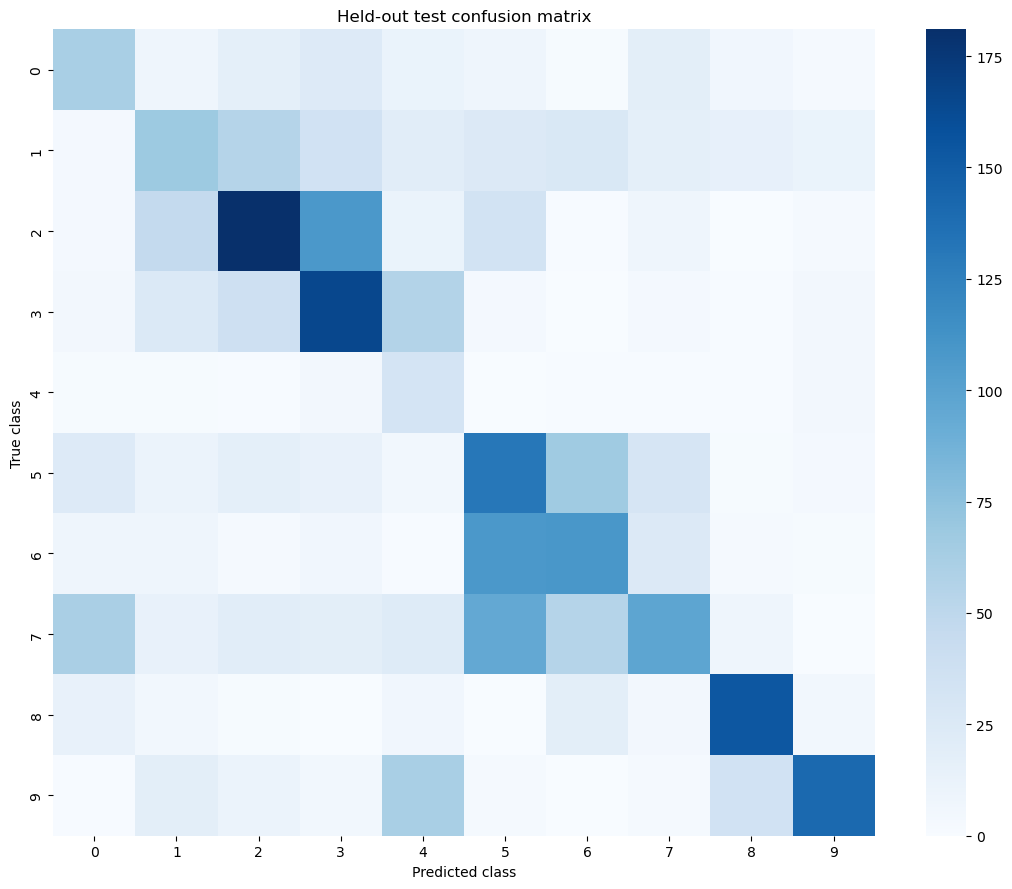

In [6]:
truth, predictions = [], []
final_model.eval()
with torch.no_grad():
    for inputs, targets in final_loaders['test']:
        logits = final_model(inputs.to(DEVICE, non_blocking=True))
        truth.extend(targets.tolist())
        predictions.extend(logits.argmax(dim=1).cpu().tolist())
report = pd.DataFrame(classification_report(
    truth, predictions, target_names=GALAXY10_CLASS_NAMES,
    output_dict=True, zero_division=0
)).transpose()
display(report)
matrix = confusion_matrix(truth, predictions)
figure, axis = plt.subplots(figsize=(11, 9))
sns.heatmap(matrix, cmap='Blues', ax=axis)
axis.set(xlabel='Predicted class', ylabel='True class', title='Held-out test confusion matrix')
figure.tight_layout()